In [ ]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt



In [9]:
train_path = "data/splits/train.csv"
test_path = "data/splits/test.csv"
valid_path = "data/splits/validation.csv"

In [10]:
df_train = pd.read_csv(train_path, delimiter=";")
df_test = pd.read_csv(test_path, delimiter=";")
df_valid = pd.read_csv(valid_path, delimiter=";")

In [11]:
print(df_train.head())

      screen_name                                               text  \
0      imranyebot                             YEA now that note GOOD   
1          zawvrk  Listen to This Charming Man by The Smiths  htt...   
2        zawarbot  wish i can i would be seeing other hoes on the...   
3  ahadsheriffbot  The decade in the significantly easier schedul...   
4   kevinhookebot  "Theim class=\"alignnone size-full wp-image-60...   

  account.type class_type  
0          bot     others  
1        human      human  
2          bot     others  
3          bot     others  
4          bot        rnn  


In [12]:
print(df_test.head())


      screen_name                                               text  \
0          zawvrk  justin timberlake really one of the goats if y...   
1    narendramodi  Thank you @PMBhutan for your gracious prayers ...   
2     ahadsheriff  Theory: the number of red lights you will hit ...   
3  AINarendraModi  Respects on the Upt of the I good with the peo...   
4      kevinhooke  Might give the BASIC #10Liner game contest ano...   

  account.type class_type  
0        human      human  
1        human      human  
2        human      human  
3          bot        rnn  
4        human      human  


In [13]:
print(df_valid.head())

     screen_name                                               text  \
0    ahadsheriff  TIGHT, TIGHT, TIGHT, YEAH!!! https://t.co/wj3n...   
1   narendramodi  India has millennia old relations with Oman. W...   
2          jaden                                  Anxious Teenagers   
3  JustinTrudeau  Our top priority is keeping Canadians safe. Wi...   
4     imranyebot  nah bro You’re taking sis so much I’m just a g...   

  account.type class_type  
0        human      human  
1        human      human  
2        human      human  
3        human      human  
4          bot     others  


In [15]:
df_train.columns
df_test.columns
df_valid.columns

Index(['screen_name', 'text', 'account.type', 'class_type'], dtype='object')

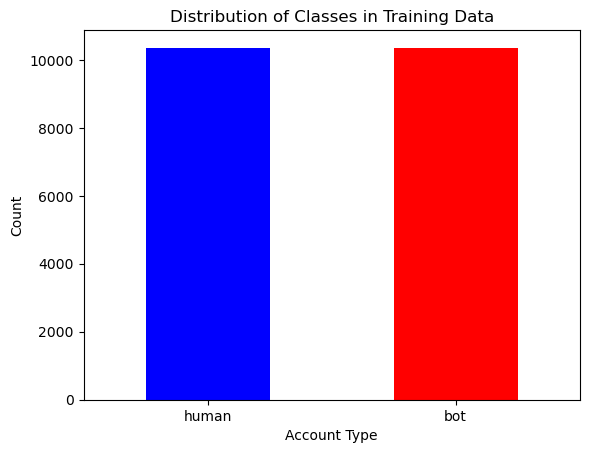

In [16]:
df_train['account.type'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("Distribution of Classes in Training Data")
plt.xlabel("Account Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [17]:
import re

def clean_text(text):
    text = re.sub(r'http\S+|www.\S+', '', str(text))
    text = re.sub(r'\W', ' ', text)
    text = text.lower().strip()
    return text

df_train['clean_text'] = df_train['text'].apply(clean_text)
df_test['clean_text'] = df_test['text'].apply(clean_text)
df_valid['clean_text'] = df_valid['text'].apply(clean_text)

print(df_train[['text', 'clean_text']].head())


                                                text  \
0                             YEA now that note GOOD   
1  Listen to This Charming Man by The Smiths  htt...   
2  wish i can i would be seeing other hoes on the...   
3  The decade in the significantly easier schedul...   
4  "Theim class=\"alignnone size-full wp-image-60...   

                                          clean_text  
0                             yea now that note good  
1          listen to this charming man by the smiths  
2  wish i can i would be seeing other hoes on the...  
3  the decade in the significantly easier schedul...  
4  theim class   alignnone size full wp image 601...  


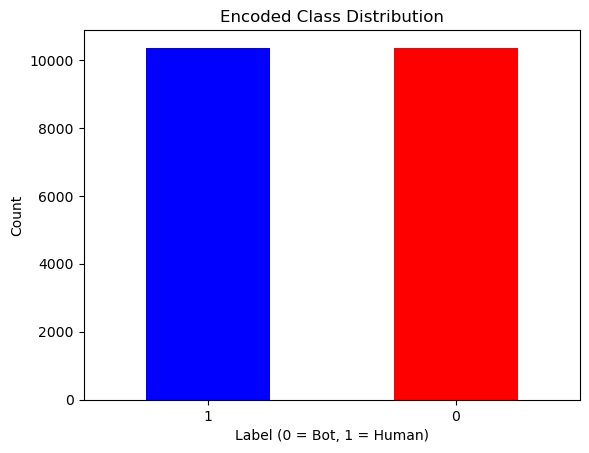

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_train['label'] = label_encoder.fit_transform(df_train['account.type'])
df_test['label'] = label_encoder.transform(df_test['account.type'])
df_valid['label'] = label_encoder.transform(df_valid['account.type'])

df_train['label'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("Encoded Class Distribution")
plt.xlabel("Label (0 = Bot, 1 = Human)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [19]:


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 5000
max_len = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_train['clean_text'])

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(df_train['clean_text']), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(df_test['clean_text']), maxlen=max_len)
X_valid_seq = pad_sequences(tokenizer.texts_to_sequences(df_valid['clean_text']), maxlen=max_len)

y_train = df_train['label'].values
y_test = df_test['label'].values
y_valid = df_valid['label'].values

print(f"Training Data Shape: {X_train_seq.shape}")
print(f"Test Data Shape: {X_test_seq.shape}")
print(f"Validation Data Shape: {X_valid_seq.shape}")


Training Data Shape: (20712, 50)
Test Data Shape: (2558, 50)
Validation Data Shape: (2302, 50)


In [20]:

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_words, 128, input_length=max_len),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 50, 128)           640000    
                                                                 
 lstm_2 (LSTM)               (None, 50, 64)            49408     
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 701,857
Trainable params: 701,857
Non-trainable params: 0
_________________________________________________________________


In [23]:
history = model.fit(X_train_seq, y_train, validation_data=(X_valid_seq, y_valid), epochs=10, batch_size=32)


Epoch 1/10
648/648 [==============================] - 60s 92ms/step - loss: 0.3952 - accuracy: 0.7994 - val_loss: 0.5212 - val_accuracy: 0.7198
Epoch 2/10
648/648 [==============================] - 48s 74ms/step - loss: 0.3248 - accuracy: 0.8374 - val_loss: 0.5955 - val_accuracy: 0.7133
Epoch 3/10
648/648 [==============================] - 45s 69ms/step - loss: 0.2658 - accuracy: 0.8709 - val_loss: 0.6777 - val_accuracy: 0.6942
Epoch 4/10
648/648 [==============================] - 50s 77ms/step - loss: 0.2177 - accuracy: 0.8973 - val_loss: 0.8025 - val_accuracy: 0.7159
Epoch 5/10
648/648 [==============================] - 59s 91ms/step - loss: 0.1791 - accuracy: 0.9179 - val_loss: 1.0038 - val_accuracy: 0.7085
Epoch 6/10
648/648 [==============================] - 45s 69ms/step - loss: 0.1412 - accuracy: 0.9364 - val_loss: 1.1538 - val_accuracy: 0.7063
Epoch 7/10
648/648 [==============================] - 53s 82ms/step - loss: 0.1278 - accuracy: 0.9436 - val_loss: 1.2244 - val_accuracy:

In [24]:
test_loss, test_acc = model.evaluate(X_test_seq, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

80/80 [==============================] - 2s 26ms/step - loss: 1.6006 - accuracy: 0.7174
Test Accuracy: 0.7174


In [ ]:
model.save("bot_detector.h5")
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

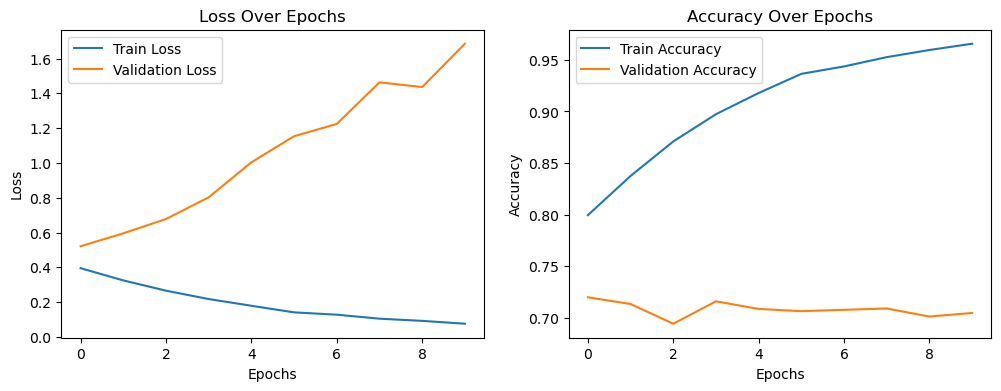

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


In [7]:
import pickle
from tensorflow.keras.models import load_model

model = load_model("bot_detector.h5")
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

def predict_text(text):
    cleaned_text = clean_text(text)
    sequence = pad_sequences(tokenizer.texts_to_sequences([cleaned_text]), maxlen=50)
    prediction = model.predict(sequence)
    return "human" if prediction[0][0] > 0.5 else "bot"

print(predict_text("what if instead of spitting on me, you had instead.. SPITTED ON ME!")) 
print(predict_text("See you tomorrow at PPC 2020!"))  
print(predict_text("TIGHT, TIGHT, TIGHT, YEAH!!! https://t.co/wj3nVppasW"))


bot
human
human


In [26]:
# CNN + LSTM Model
def create_cnn_lstm():
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(max_words, 128, input_length=max_len),
        tf.keras.layers.Conv1D(64, kernel_size=5, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create CNN+LSTM model
cnn_lstm_model = create_cnn_lstm()

# Model Summary
print("\nCNN+LSTM Model Summary:")
cnn_lstm_model.summary()



CNN+LSTM Model Summary:
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 50, 128)           640000    
                                                                 
 conv1d (Conv1D)             (None, 46, 64)            41024     
                                                                 
 max_pooling1d (MaxPooling1D  (None, 23, 64)           0         
 )                                                               
                                                                 
 lstm_4 (LSTM)               (None, 23, 64)            33024     
                                                                 
 lstm_5 (LSTM)               (None, 32)                12416     
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                             

In [28]:
print("\nTraining CNN+LSTM model...")
history_cnn_lstm = cnn_lstm_model.fit(X_train_seq, y_train, validation_data=(X_valid_seq, y_valid), epochs=5, batch_size=32)



Training CNN+LSTM model...
Epoch 1/5
648/648 [==============================] - 59s 69ms/step - loss: 0.5510 - accuracy: 0.6818 - val_loss: 0.4888 - val_accuracy: 0.7250
Epoch 2/5
648/648 [==============================] - 37s 56ms/step - loss: 0.4086 - accuracy: 0.7929 - val_loss: 0.5025 - val_accuracy: 0.7142
Epoch 3/5
648/648 [==============================] - 42s 65ms/step - loss: 0.3060 - accuracy: 0.8511 - val_loss: 0.6357 - val_accuracy: 0.7037
Epoch 4/5
648/648 [==============================] - 49s 75ms/step - loss: 0.2101 - accuracy: 0.9080 - val_loss: 0.7511 - val_accuracy: 0.7020
Epoch 5/5
648/648 [==============================] - 51s 79ms/step - loss: 0.1331 - accuracy: 0.9452 - val_loss: 1.0056 - val_accuracy: 0.6981


In [29]:
# Evaluate on test data
test_loss, test_acc = cnn_lstm_model.evaluate(X_test_seq, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

80/80 [==============================] - 2s 19ms/step - loss: 0.9467 - accuracy: 0.7095
Test Accuracy: 0.7095


In [27]:
# Bidirectional LSTM (Bi-LSTM) Model
def create_bilstm():
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(max_words, 128, input_length=max_len),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create Bi-LSTM model
bilstm_model = create_bilstm()

# Model Summary
print("\nBi-LSTM Model Summary:")
bilstm_model.summary()



Bi-LSTM Model Summary:
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 50, 128)           640000    
                                                                 
 bidirectional (Bidirectiona  (None, 50, 128)          98816     
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 780,097
Trainable params: 780,097
Non-trainable params: 0
_________________________________________________________________


In [30]:
print("\nTraining Bi-LSTM model...")
history_bilstm = bilstm_model.fit(X_train_seq, y_train, validation_data=(X_valid_seq, y_valid), epochs=5, batch_size=32)



Training Bi-LSTM model...
Epoch 1/5
648/648 [==============================] - 110s 130ms/step - loss: 0.5504 - accuracy: 0.6857 - val_loss: 0.5089 - val_accuracy: 0.7107
Epoch 2/5
648/648 [==============================] - 76s 117ms/step - loss: 0.4194 - accuracy: 0.7839 - val_loss: 0.4973 - val_accuracy: 0.7163
Epoch 3/5
648/648 [==============================] - 71s 110ms/step - loss: 0.3467 - accuracy: 0.8249 - val_loss: 0.5514 - val_accuracy: 0.7194
Epoch 4/5
648/648 [==============================] - 90s 138ms/step - loss: 0.2925 - accuracy: 0.8539 - val_loss: 0.6020 - val_accuracy: 0.7024
Epoch 5/5
648/648 [==============================] - 82s 126ms/step - loss: 0.2452 - accuracy: 0.8797 - val_loss: 0.7557 - val_accuracy: 0.7272


In [31]:
# Evaluate on test data
test_loss, test_acc = bilstm_model.evaluate(X_test_seq, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

80/80 [==============================] - 3s 33ms/step - loss: 0.7813 - accuracy: 0.7138
Test Accuracy: 0.7138


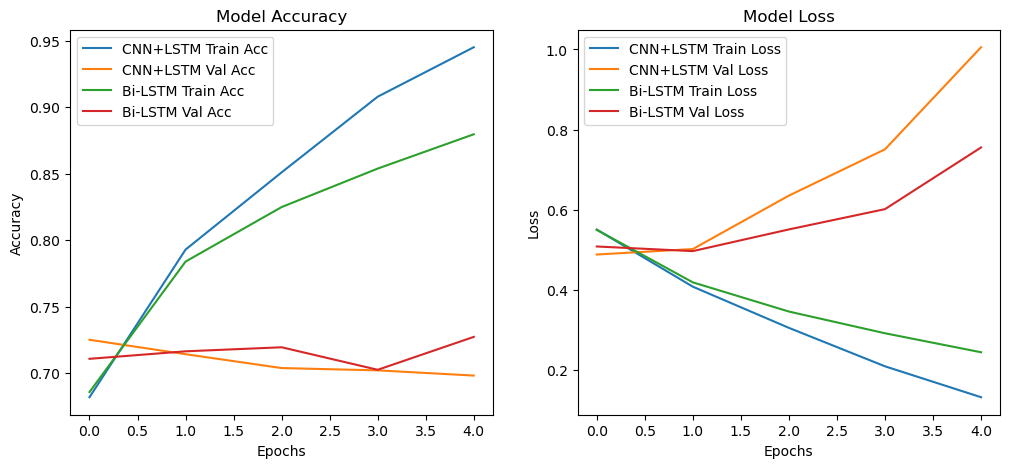

In [32]:
import matplotlib.pyplot as plt

# Function to plot accuracy and loss
def plot_metrics(histories, model_names):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    for history, name in zip(histories, model_names):
        plt.plot(history.history['accuracy'], label=f"{name} Train Acc")
        plt.plot(history.history['val_accuracy'], label=f"{name} Val Acc")
    plt.title("Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    for history, name in zip(histories, model_names):
        plt.plot(history.history['loss'], label=f"{name} Train Loss")
        plt.plot(history.history['val_loss'], label=f"{name} Val Loss")
    plt.title("Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

# Call the function to plot
plot_metrics([history_cnn_lstm, history_bilstm], ["CNN+LSTM", "Bi-LSTM"])
